In [32]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *

In [33]:
atlas,_= am.get_atlas(atlas_str='MNISymC2')
dist = compute_dist(atlas.world.T, resolution=1)


In [34]:
# Load group prior
model_name = f'/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii'
_, cmap, labels = nt.read_lut(f'{BASE_DIR}/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32.lut')
U = atlas.read_data(BASE_DIR + model_name)
U = U.T
sym_type = 'sym'

# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(U, prior_type='prob', atlas=atlas,
                                        sym_type='sym')

C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\arrangements.py:1879: UserWarning: The marginal probability has 18207 voxels zero values - adding small value to avoid -inf
  warnings.warn(f'The marginal probability has {zero_voxl} voxels'


In [35]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

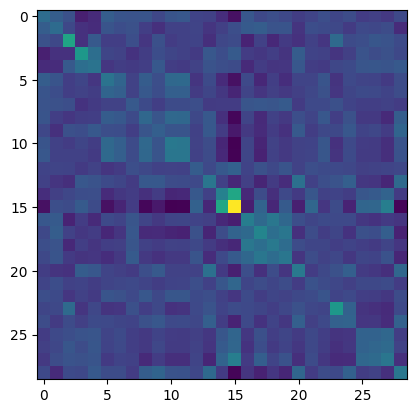

In [43]:
plt.imshow(GL_mdtb)

In [44]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [45]:
def evaluate_cos(D, ytrain,info, Vs, ytest, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}
    cos_ols_dict = {}

    ytest = pt.tensor(ytest,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        y_subset = ytrain[:, task_subset_indices, :]

        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().cpu().numpy()
        cos_ols = cos_ols.item()

        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
        U_hat_HBP = [HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)]        
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

In [38]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0



In [46]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 32)
data_test = data_mdtb_s2_run


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


Likelihood decreased - terminating on iteration 90


In [47]:
offsets = np.logspace(-10, 10, num=50)
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=400,n_tasks=8,seed=54)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb, data_mdtb_s2_run, VL_mdtb_2,M_2)


Processing combination: 0
Likelihood decreased - terminating on iteration 50
Subject:0:0.0147s
Subject:1:0.0141s
Subject:2:0.0129s
Subject:3:0.0121s
Subject:4:0.0128s
Subject:5:0.0143s
Subject:6:0.0136s
Subject:7:0.0130s
Subject:8:0.0134s
Subject:9:0.0110s
Subject:10:0.0135s
Subject:11:0.0121s
Subject:12:0.0116s
Subject:13:0.0128s
Subject:14:0.0119s
Subject:15:0.0122s
Subject:16:0.0115s
Subject:17:0.0108s
Subject:18:0.0119s
Subject:19:0.0112s
Subject:20:0.0110s
Subject:21:0.0123s
Subject:22:0.0120s
Subject:23:0.0109s
Processing combination: 1
Likelihood decreased - terminating on iteration 99
Subject:0:0.0159s
Subject:1:0.0138s
Subject:2:0.0143s
Subject:3:0.0138s
Subject:4:0.0132s
Subject:5:0.0105s
Subject:6:0.0119s
Subject:7:0.0119s
Subject:8:0.0117s
Subject:9:0.0114s
Subject:10:0.0120s
Subject:11:0.0118s
Subject:12:0.0110s
Subject:13:0.0138s
Subject:14:0.0127s
Subject:15:0.0121s
Subject:16:0.0111s
Subject:17:0.0120s
Subject:18:0.0122s
Subject:19:0.0121s
Subject:20:0.0123s
Subject:21:

In [55]:
# save the dataframe in the current directory
# D_mdtb.to_csv('D_mdtb_comp.csv.gz', index=False,compression='gzip')

# load the dataframe
D_mdtb = pd.read_csv('D_mdtb.csv')

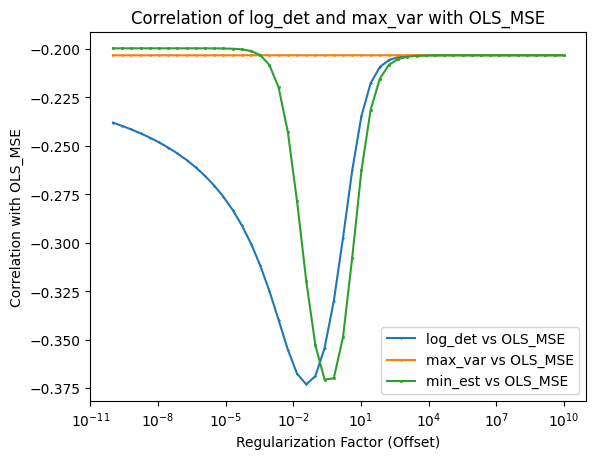

In [56]:
offsets = D_mdtb['offset'].unique()
log_det_corrs = []
max_var_corrs = []
min_est_corrs = []

for offset in offsets:
    subset = D_mdtb[D_mdtb['offset'] == offset]
    
    log_det_corr = np.corrcoef(subset['log_det'], subset['cos_ols'])[0, 1]
    log_det_corrs.append(log_det_corr)
    
    max_var_corr = np.corrcoef(subset['max_var'], subset['cos_ols'])[0, 1]
    max_var_corrs.append(max_var_corr)

    min_est_corr = np.corrcoef(subset['min_est'], subset['cos_ols'])[0, 1]
    min_est_corrs.append(-1 * min_est_corr)


plt.plot(offsets, log_det_corrs, label='log_det vs OLS_MSE', marker='x',markersize=1)
plt.plot(offsets, max_var_corrs, label='max_var vs OLS_MSE', marker='o',markersize=1)
plt.plot(offsets, min_est_corrs, label='min_est vs OLS_MSE', marker='s',markersize=1)

plt.xscale('log')  
plt.xlabel('Regularization Factor (Offset)')
plt.ylabel('Correlation with OLS_MSE')
plt.title('Correlation of log_det and max_var with OLS_MSE')
plt.legend()
plt.show()

Offset with highest correlation: 0.0372759372031493 (Correlation: -0.8650707036239954)


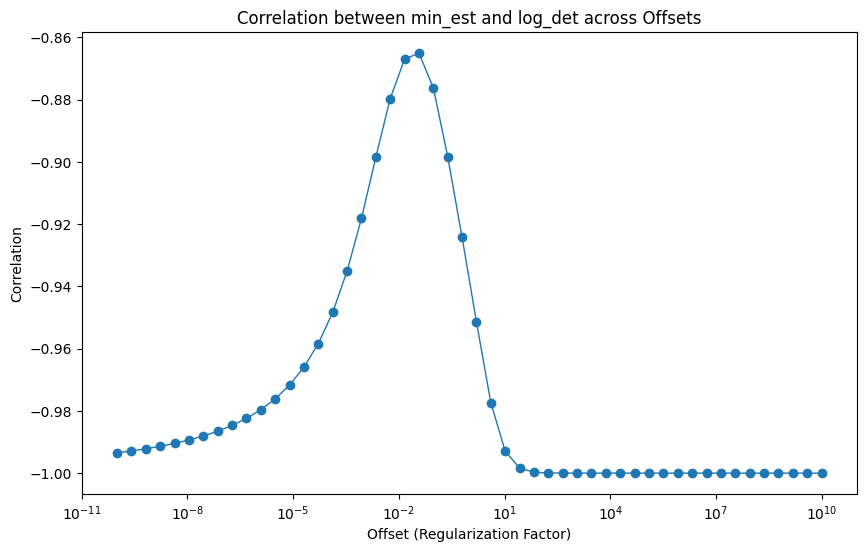

In [57]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtb[D_mdtb['offset'] == offset]
    corr, _ = pearsonr(data['min_est'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and log_det across Offsets')


# print regularization factor with highest correlation
max_corr = max(corr_list)
max_corr_offset = offsets[corr_list.index(max_corr)]
print(f'Offset with highest correlation: {max_corr_offset} (Correlation: {max_corr})')

In [16]:
# print regularization factor with highest correlation
max_corr = max(corr_list)
max_corr_offset = offsets[corr_list.index(max_corr)]
print(f'Offset with highest correlation: {max_corr_offset} (Correlation: {max_corr})')

Offset with highest correlation: 0.03727593720314938 (Correlation: -0.8650707036239953)


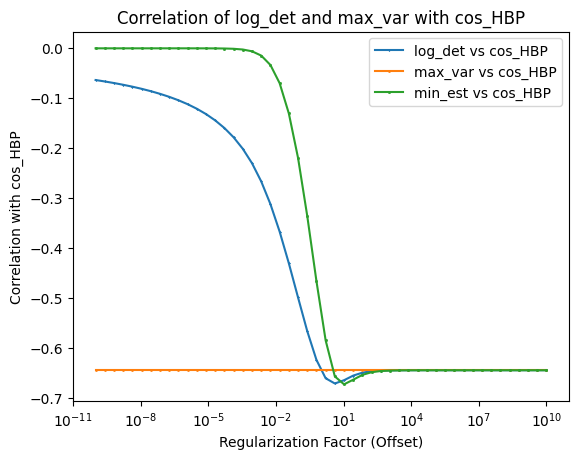

In [58]:
offsets = D_mdtb['offset'].unique()
log_det_corrs = []
max_var_corrs = []
min_est_corrs = []

for offset in offsets:
    subset = D_mdtb[D_mdtb['offset'] == offset]
    
    log_det_corr = np.corrcoef(subset['log_det'], subset['cos_HBP'])[0, 1]
    log_det_corrs.append(log_det_corr)
    
    max_var_corr = np.corrcoef(subset['max_var'], subset['cos_HBP'])[0, 1]
    max_var_corrs.append(max_var_corr)

    min_est_corr = np.corrcoef(subset['min_est'], subset['cos_HBP'])[0, 1]
    min_est_corrs.append(-1 * min_est_corr)


plt.plot(offsets, log_det_corrs, label='log_det vs cos_HBP', marker='x',markersize=1)
plt.plot(offsets, max_var_corrs, label='max_var vs cos_HBP', marker='o',markersize=1)
plt.plot(offsets, min_est_corrs, label='min_est vs cos_HBP', marker='s',markersize=1)

plt.xscale('log')  
plt.xlabel('Regularization Factor (Offset)')
plt.ylabel('Correlation with cos_HBP')
plt.title('Correlation of log_det and max_var with cos_HBP')
plt.legend()
plt.show()

In [53]:
# print correlation between log det and min_est at each offset
corr_list = []
for offset in offsets:
    data = D_mdtb[D_mdtb['offset'] == offset]
    corr, _ = pearsonr(data['cos_HBP'], data['log_det'])
    corr_list.append(corr)
    print(f'Offset: {offset}, Correlation: {corr}')

Offset: 1e-10, Correlation: -0.012654195615743519
Offset: 2.5595479226995335e-10, Correlation: -0.016022704617209248
Offset: 6.551285568595495e-10, Correlation: -0.019713119301437924
Offset: 1.67683293681101e-09, Correlation: -0.023773375965837947
Offset: 4.291934260128778e-09, Correlation: -0.02826130501336296
Offset: 1.0985411419875573e-08, Correlation: -0.03324728177424756
Offset: 2.8117686979742307e-08, Correlation: -0.0388177623850023
Offset: 7.196856730011529e-08, Correlation: -0.045080059820003265
Offset: 1.8420699693267165e-07, Correlation: -0.05216888128994415
Offset: 4.7148663634573897e-07, Correlation: -0.06025539964847901
Offset: 1.2067926406393288e-06, Correlation: -0.06956001067974356
Offset: 3.088843596477485e-06, Correlation: -0.08037048714657091
Offset: 7.906043210907702e-06, Correlation: -0.09306801041121131
Offset: 2.0235896477251556e-05, Correlation: -0.10816442535236
Offset: 5.1794746792312125e-05, Correlation: -0.1263543260875857
Offset: 0.0001325711365590111, Cor